[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part6-media-optimization/sec6.3_geo_experiment.ipynb)

# Geo Incrementality Experiment: Design, Power, and Lift

**Companion notebook for Section 6.3 of *Marketing Science in Python*.**

An MMM can flag a channel whose ROAS is uncertain, but observational data
cannot manufacture the missing counterfactual. This notebook creates that
counterfactual with a randomized matched-pair geo experiment. The synthetic
panel has a hidden, planted marginal ROAS, so we can check the complete chain:

1. screen markets on pre-period similarity;
2. form matched pairs and randomize within each pair;
3. simulate power before looking at outcomes;
4. estimate lift with DiD and a synthetic-control robustness check;
5. challenge the estimate with in-space and in-time placebos; and
6. open the ground truth only after the estimate is frozen.

## Step 1: Freeze the Design Before Looking at Results

Put every choice that could move after seeing the answer in one place. In a
real test, this cell belongs in the design document before launch.

In [1]:
from __future__ import annotations

import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
from scipy.optimize import minimize
from PIL import Image

DESIGN = {
    "seed": 20260888,
    "channel": "Google Search",
    "test_start": "2024-02-05",
    "test_end": "2024-03-25",
    "test_weeks": 8,
    "n_pairs": 8,
    # The test cuts spend, so the contrast is negative. `direction` records that
    # once; the estimator and the power simulation both read it instead of
    # assuming a scale-up. A reduce design flips the sign of the DiD coefficient
    # and of the spend denominator, and code that assumes "bigger is treated"
    # silently reports a negative standard error or never detects an effect.
    "spend_multiplier": 0.70,
    "direction": -1,
    # Gross margin on incremental revenue. A Search dollar is worth keeping only
    # if it returns more than 1 / margin in revenue, so this fixes the hurdle the
    # decision rule compares against.
    "contribution_margin": 0.40,
    "power_durations": (4, 6, 8, 10),
    "power_spend_multipliers": (0.80, 0.70, 0.60),
    "power_roas_grid": tuple(np.round(np.arange(0.0, 0.81, 0.10), 2)),
    "power_simulations": 24,
    "alpha": 0.05,
}
DESIGN["hurdle_roas"] = round(1.0 / DESIGN["contribution_margin"], 2)

pd.set_option("display.float_format", "{:.3f}".format)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

In [2]:
# Colab bootstrap: make the in-repo `msbook` helpers available.
import sys
try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    _REPO = "https://github.com/takechanman1228/marketing-science-in-python.git"
    subprocess.run(["git", "clone", "-q", _REPO], check=True)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", "marketing-science-in-python"],
        check=True,
    )
    import msbook  # noqa: F401

from msbook.paths import DATA_DIR, chapter_images

DATA_PATH = DATA_DIR / "generated" / "part6" / "sec6.3-geo" / "geo_panel.csv"
TRUTH_PATH = DATA_DIR / "generated" / "part6" / "sec6.3-geo" / "geo_ground_truth.csv"
IMG_DIR = chapter_images(part="6", chapter="sec6.3")


def save_chapter_figure(fig, name: str) -> None:
    """Save the PNG used by Quarto and its compact WebP sibling."""
    png_path = IMG_DIR / name
    fig.savefig(png_path, dpi=150, bbox_inches="tight", facecolor="white")
    with Image.open(png_path) as image:
        image.save(png_path.with_suffix(".webp"), "WEBP", quality=85, method=6)


print("Frozen design")
for key, value in DESIGN.items():
    print(f"  {key}: {value}")

Frozen design
  seed: 20260888
  channel: Google Search
  test_start: 2024-02-05
  test_end: 2024-03-25
  test_weeks: 8
  n_pairs: 8
  spend_multiplier: 0.7
  direction: -1
  contribution_margin: 0.4
  power_durations: (4, 6, 8, 10)
  power_spend_multipliers: (0.8, 0.7, 0.6)
  power_roas_grid: (np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8))
  power_simulations: 24
  alpha: 0.05
  hurdle_roas: 2.5


## Step 2: Load and Orient to the Geo Panel

The observed file contains only four fields: anonymous geography, Monday,
channel spend, and revenue. There is no treatment flag and no true-lift
column. The spend change itself is visible, as it would be in any real
experiment; what stays sealed until the recovery check is the planted answer.

In [3]:
panel = pd.read_csv(DATA_PATH, parse_dates=["week"])
print(f"Rows: {len(panel):,}")
print(f"Geographies: {panel['geo'].nunique()}")
print(f"Weeks: {panel['week'].nunique()}")
print(f"Range: {panel['week'].min().date()} to {panel['week'].max().date()}")
panel.head()

Rows: 4,160
Geographies: 40
Weeks: 104
Range: 2022-04-04 to 2024-03-25


,geo,week,spend,revenue
0,Geo 01,2022-04-04,10226.230,81466.530
1,Geo 01,2022-04-11,10892.680,81861.710
2,Geo 01,2022-04-18,10456.530,81593.780
3,Geo 01,2022-04-25,9848.270,84367.040
4,Geo 01,2022-05-02,10270.710,83778.950


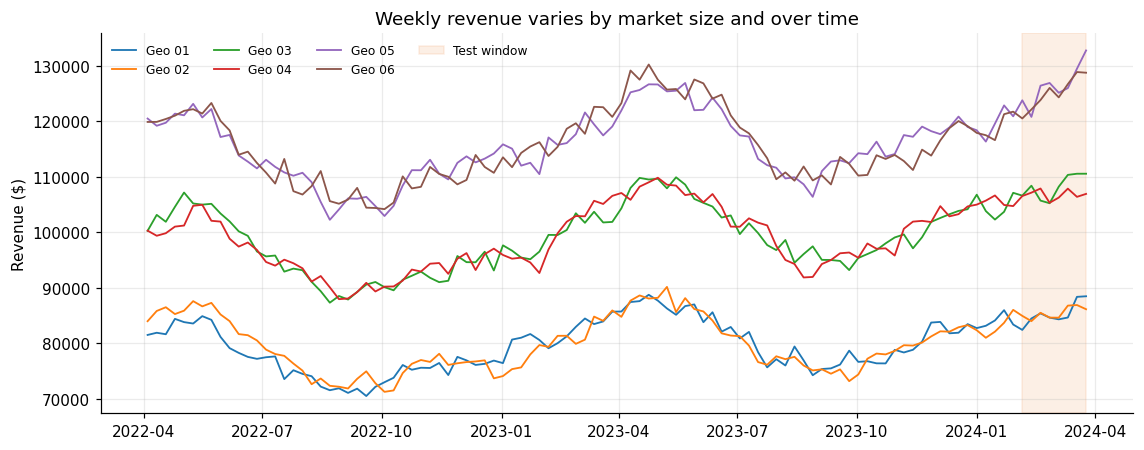

In [4]:
sample_geos = panel["geo"].drop_duplicates().iloc[:6]
fig, ax = plt.subplots(figsize=(10.5, 4.2))
for geo in sample_geos:
    geo_data = panel.loc[panel["geo"] == geo]
    ax.plot(geo_data["week"], geo_data["revenue"], lw=1.2, label=geo)
ax.axvspan(
    pd.Timestamp(DESIGN["test_start"]),
    pd.Timestamp(DESIGN["test_end"]),
    color="#ed7d31",
    alpha=0.12,
    label="Test window",
)
ax.set(title="Weekly revenue varies by market size and over time", ylabel="Revenue ($)")
ax.legend(ncol=4, fontsize=8, frameon=False)
fig.tight_layout()
plt.show()
plt.close(fig)

## Step 3: Screen, Match, Then Randomize

Screening and assignment are two separate decisions. First, keep markets whose
pre-period revenue follows the rest of the business. Next, match the screened
markets on size and normalized trend. Only then randomize one geography in each
pair to treatment. The randomization is the source of identification; matching
is there to reduce noise.

In [5]:
def market_metrics(panel: pd.DataFrame, test_start: str | pd.Timestamp) -> pd.DataFrame:
    """Compute pre-period similarity, size, and normalized trend by geography."""
    work = panel.copy()
    work["week"] = pd.to_datetime(work["week"])
    pre = work.loc[work["week"] < pd.Timestamp(test_start)]
    wide = pre.pivot(index="week", columns="geo", values="revenue").sort_index()
    aggregate = wide.sum(axis=1)

    rows = []
    x = np.arange(len(wide), dtype=float)
    for geo in wide.columns:
        series = wide[geo]
        leave_one_out = aggregate - series
        mean_revenue = float(series.mean())
        rows.append(
            {
                "geo": str(geo),
                "pre_corr": float(series.corr(leave_one_out)),
                "pre_mean_revenue": mean_revenue,
                "pre_trend": float(np.polyfit(x, series.to_numpy(), 1)[0] / mean_revenue),
            }
        )
    return pd.DataFrame(rows).sort_values("geo").reset_index(drop=True)


def screen_pair_and_assign(
    panel: pd.DataFrame,
    test_start: str | pd.Timestamp,
    n_pairs: int = 8,
    seed: int = 20260888,
) -> pd.DataFrame:
    """Screen on correlation, greedily match on size/trend, randomize in pairs."""
    metrics = market_metrics(panel, test_start)
    selected = (
        metrics.sort_values(["pre_corr", "geo"], ascending=[False, True])
        .head(2 * n_pairs)
        .copy()
    )

    ordered = list(
        selected.sort_values(["pre_mean_revenue", "pre_trend", "geo"]).index
    )
    pairs = [(ordered[i], ordered[i + 1]) for i in range(0, len(ordered), 2)]

    rng = np.random.default_rng(seed)
    records = []
    for pair_number, (left, right) in enumerate(pairs, start=1):
        geos = sorted([str(selected.loc[left, "geo"]), str(selected.loc[right, "geo"])])
        treated_index = int(rng.integers(0, 2))
        for index, geo in enumerate(geos):
            row = selected.loc[selected["geo"] == geo].iloc[0]
            records.append(
                {
                    "geo": geo,
                    "pair": pair_number,
                    "role": "test" if index == treated_index else "control",
                    "pre_corr": float(row["pre_corr"]),
                    "pre_mean_revenue": float(row["pre_mean_revenue"]),
                    "pre_trend": float(row["pre_trend"]),
                }
            )
    return pd.DataFrame(records).sort_values(["pair", "role", "geo"]).reset_index(drop=True)


assignment = screen_pair_and_assign(
    panel,
    DESIGN["test_start"],
    n_pairs=DESIGN["n_pairs"],
    seed=DESIGN["seed"],
)
print(assignment[["pair", "geo", "role", "pre_corr", "pre_mean_revenue", "pre_trend"]].to_string(index=False))

 pair    geo    role  pre_corr  pre_mean_revenue  pre_trend
    1 Geo 01 control     0.930         79518.029      0.001
    1 Geo 02    test     0.924         79777.014      0.000
    2 Geo 03 control     0.955         98813.527      0.001
    2 Geo 04    test     0.933         98827.307      0.001
    3 Geo 05 control     0.944        115378.013      0.000
    3 Geo 06    test     0.953        115371.779      0.000
    4 Geo 07 control     0.917        131505.854     -0.000
    4 Geo 08    test     0.893        129424.224      0.000
    5 Geo 10 control     0.934        156671.954      0.001
    5 Geo 09    test     0.926        158797.571      0.001
    6 Geo 11 control     0.921        178784.719      0.000
    6 Geo 12    test     0.918        178266.036      0.000
    7 Geo 13 control     0.950        210929.703      0.000
    7 Geo 14    test     0.938        208366.745      0.000
    8 Geo 15 control     0.919        255596.643      0.001
    8 Geo 16    test     0.933        25

## Step 4: Simulate Power Before Spending

Power is a property of this panel, assignment, duration, and spend change. It
is not a generic rule such as "always run six weeks." We repeatedly choose a
historical pseudo-launch, inject a candidate lift, rerun the same clustered
DiD, and count how often the one planned test rejects zero in the right
direction. The 80% crossing is the simulated minimum detectable ROAS (MDE).

In [6]:
def prepare_did_panel(
    panel: pd.DataFrame,
    assignment: pd.DataFrame,
    test_start: str | pd.Timestamp,
    test_end: str | pd.Timestamp,
) -> pd.DataFrame:
    """Attach frozen roles and build the binary DiD regressors."""
    work = panel.copy()
    work["week"] = pd.to_datetime(work["week"])
    roles = assignment[["geo", "pair", "role"]].copy()
    work = work.merge(roles, on="geo", how="inner", validate="many_to_one")
    start = pd.Timestamp(test_start)
    end = pd.Timestamp(test_end)
    work = work.loc[work["week"] <= end].copy()
    work["treat"] = (work["role"] == "test").astype(int)
    work["post"] = work["week"].between(start, end).astype(int)
    return work.sort_values(["geo", "week"]).reset_index(drop=True)


def fit_did(
    panel: pd.DataFrame,
    assignment: pd.DataFrame,
    test_start: str | pd.Timestamp,
    test_end: str | pd.Timestamp,
    spend_multiplier: float = 1.25,
    cluster_by: str = "geo",
) -> dict:
    """Fit clustered DiD and translate its geo-week coefficient to ROAS.

    `cluster_by` chooses the unit the standard error treats as independent.
    "geo" gives 16 clusters; "pair" gives 8, which is the number of coin flips
    the design actually made. The pair version is the conservative reading and
    Step 10c runs it as a pre-specified sensitivity.
    """
    analysis = prepare_did_panel(panel, assignment, test_start, test_end)
    # Pair-by-post terms honor the blocked randomization by allowing every
    # matched pair its own common movement during the test window.
    model = smf.ols(
        "revenue ~ C(geo) + C(pair):post + treat:post", data=analysis
    ).fit(
        cov_type="cluster", cov_kwds={"groups": analysis[cluster_by]}
    )
    treated_post = (analysis["treat"] == 1) & (analysis["post"] == 1)
    incremental_spend = float(
        (analysis.loc[treated_post, "spend"] * (spend_multiplier - 1.0) / spend_multiplier).sum()
    )
    n_treated_geo_weeks = int(treated_post.sum())
    spend_per_geo_week = incremental_spend / n_treated_geo_weeks
    coefficient = float(model.params["treat:post"])
    coefficient_se = float(model.bse["treat:post"])
    # For a pull-back both the numerator and the denominator are negative, so the
    # ratio is positive: revenue given up per dollar removed. The standard error
    # has no sign, so it divides by the magnitude; using the signed denominator
    # would hand back a negative SE and swap the interval bounds.
    roas = coefficient / spend_per_geo_week
    roas_se = coefficient_se / abs(spend_per_geo_week)
    # With 16 geo clusters, normal critical values are too tight: use the
    # t distribution with G - 1 cluster degrees of freedom.
    df_clusters = int(analysis[cluster_by].nunique()) - 1
    t_crit = float(stats.t.ppf(0.975, df_clusters))
    return {
        "model": model,
        "analysis": analysis,
        "coefficient": coefficient,
        "coefficient_se": coefficient_se,
        "roas": roas,
        "roas_se": roas_se,
        "ci_low": roas - t_crit * roas_se,
        "ci_high": roas + t_crit * roas_se,
        "incremental_spend": incremental_spend,
        "n_treated_geo_weeks": n_treated_geo_weeks,
    }


def _randomize_within_pairs(assignment: pd.DataFrame, rng: np.random.Generator) -> pd.DataFrame:
    """Return a fresh one-treated-per-pair assignment."""
    records = []
    for pair_number, pair_frame in assignment.groupby("pair", sort=True):
        geos = sorted(pair_frame["geo"].astype(str))
        treated_index = int(rng.integers(0, 2))
        for index, geo in enumerate(geos):
            records.append(
                {
                    "geo": geo,
                    "pair": int(pair_number),
                    "role": "test" if index == treated_index else "control",
                }
            )
    return pd.DataFrame(records)


def simulate_power_grid(
    panel: pd.DataFrame,
    assignment: pd.DataFrame,
    durations: tuple[int, ...] = (4, 6, 8, 10),
    spend_multipliers: tuple[float, ...] = (1.15, 1.25, 1.35),
    roas_values: tuple[float, ...] = tuple(np.round(np.arange(0.0, 0.81, 0.10), 2)),
    n_sim: int = 24,
    seed: int = 20260888,
    alpha: float = 0.05,
) -> pd.DataFrame:
    """Inject lifts into historical windows and estimate detection rates."""
    history = panel.copy()
    history["week"] = pd.to_datetime(history["week"])
    history = history.loc[history["week"] < pd.Timestamp(DESIGN["test_start"])].copy()
    weeks = np.array(sorted(history["week"].unique()))
    max_duration = max(durations)
    if len(weeks) < max_duration + 36:
        raise ValueError("Power simulation needs at least 36 pre-weeks plus the longest test.")

    rng = np.random.default_rng(seed)
    detections = {
        (duration, multiplier, roas): 0
        for duration in durations
        for multiplier in spend_multipliers
        for roas in roas_values
    }

    for _ in range(n_sim):
        randomized = _randomize_within_pairs(assignment, rng)
        end_index = int(rng.integers(max_duration + 35, len(weeks)))
        pseudo_end = pd.Timestamp(weeks[end_index])

        for duration in durations:
            pseudo_start = pd.Timestamp(weeks[end_index - duration + 1])
            base = history.loc[history["week"] <= pseudo_end].copy()
            role_map = randomized.set_index("geo")["role"]
            treat_window = (
                base["geo"].map(role_map).eq("test")
                & base["week"].between(pseudo_start, pseudo_end)
            )

            for multiplier in spend_multipliers:
                planned_increment = base.loc[treat_window, "spend"] * (multiplier - 1.0)
                for roas in roas_values:
                    injected = base.copy()
                    injected.loc[treat_window, "spend"] = (
                        injected.loc[treat_window, "spend"] * multiplier
                    )
                    injected.loc[treat_window, "revenue"] = (
                        injected.loc[treat_window, "revenue"]
                        + roas * planned_increment.to_numpy()
                    )
                    estimate = fit_did(
                        injected,
                        randomized,
                        pseudo_start,
                        pseudo_end,
                        spend_multiplier=multiplier,
                    )
                    # Same small-sample t inference as fit_did's interval.
                    df_clusters = int(estimate["analysis"]["geo"].nunique()) - 1
                    t_stat = estimate["coefficient"] / estimate["coefficient_se"]
                    p_value = 2.0 * float(stats.t.sf(abs(t_stat), df_clusters))
                    # An effect counts as detected when the coefficient moves
                    # the way the contrast should move it: revenue down when
                    # spend is cut, up when it is added.
                    expected_sign = 1.0 if multiplier > 1.0 else -1.0
                    detected = (
                        p_value < alpha
                        and estimate["coefficient"] * expected_sign > 0
                    )
                    detections[(duration, multiplier, roas)] += int(detected)

    rows = [
        {
            "duration_weeks": duration,
            "spend_multiplier": multiplier,
            "injected_roas": roas,
            "detection_rate": count / n_sim,
        }
        for (duration, multiplier, roas), count in detections.items()
    ]
    return pd.DataFrame(rows).sort_values(
        ["spend_multiplier", "duration_weeks", "injected_roas"]
    ).reset_index(drop=True)


def minimum_detectable_roas(power: pd.DataFrame, threshold: float = 0.80) -> pd.DataFrame:
    """Return the smallest simulated ROAS crossing the target power."""
    rows = []
    for (multiplier, duration), group in power.groupby(
        ["spend_multiplier", "duration_weeks"], sort=True
    ):
        eligible = group.loc[group["detection_rate"] >= threshold].sort_values("injected_roas")
        rows.append(
            {
                "spend_multiplier": float(multiplier),
                "duration_weeks": int(duration),
                "mde_roas": float(eligible.iloc[0]["injected_roas"]) if len(eligible) else np.nan,
            }
        )
    return pd.DataFrame(rows)


power = simulate_power_grid(
    panel,
    assignment,
    durations=DESIGN["power_durations"],
    spend_multipliers=DESIGN["power_spend_multipliers"],
    roas_values=DESIGN["power_roas_grid"],
    n_sim=DESIGN["power_simulations"],
    seed=DESIGN["seed"],
    alpha=DESIGN["alpha"],
)
mde = minimum_detectable_roas(power)
print(mde.to_string(index=False))

 spend_multiplier  duration_weeks  mde_roas
            0.600               4     0.300
            0.600               6     0.300
            0.600               8     0.200
            0.600              10     0.200
            0.700               4     0.400
            0.700               6     0.300
            0.700               8     0.300
            0.700              10     0.200
            0.800               4     0.500
            0.800               6     0.500
            0.800               8     0.400
            0.800              10     0.300


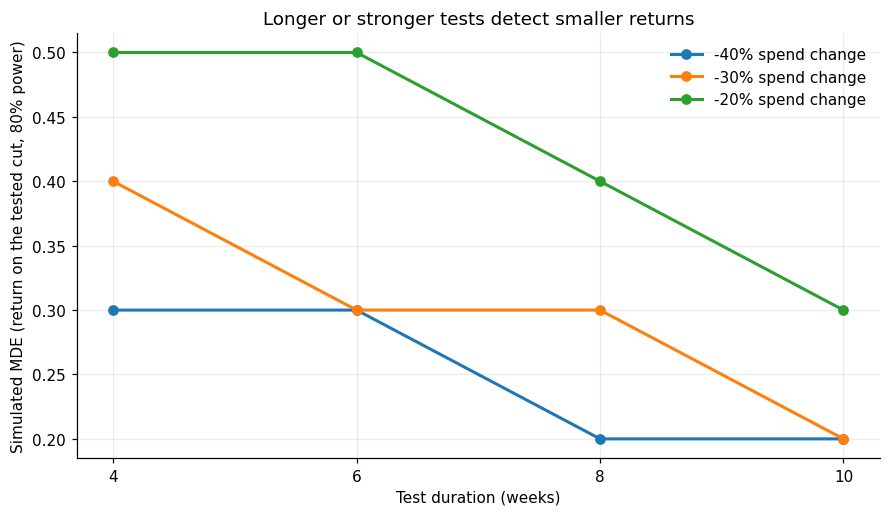

In [7]:
fig, ax = plt.subplots(figsize=(8.2, 4.8))
for multiplier, group in mde.groupby("spend_multiplier"):
    ax.plot(
        group["duration_weeks"],
        group["mde_roas"],
        marker="o",
        lw=2,
        label=f"{(multiplier - 1):.0%} spend change",
    )
ax.set(
    title="Longer or stronger tests detect smaller returns",
    xlabel="Test duration (weeks)",
    ylabel="Simulated MDE (return on the tested cut, 80% power)",
    xticks=list(DESIGN["power_durations"]),
)
ax.legend(frameon=False)
fig.tight_layout()
save_chapter_figure(fig, "mde_by_duration.png")
plt.show()
plt.close(fig)

The curve is the design rule. If the business expects a ROAS below the MDE,
either widen the spend contrast, design a follow-up test, add informative markets,
or do not launch a test that cannot answer its own question.

## Step 5: Run the Frozen Test

The observed panel already contains the planned spend change in the treatment
geographies during the frozen window. Plot both groups before estimating.

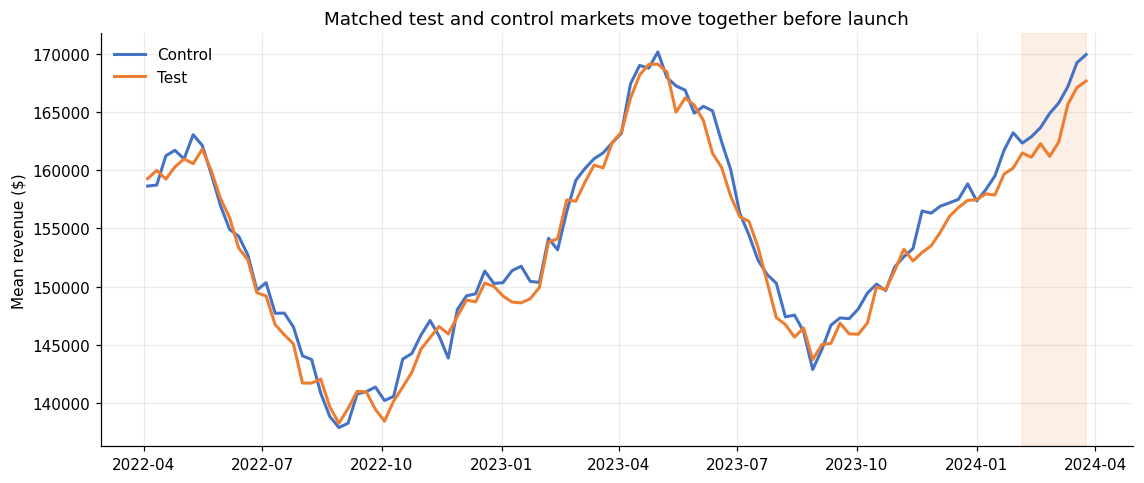

In [8]:
analysis = prepare_did_panel(
    panel, assignment, DESIGN["test_start"], DESIGN["test_end"]
)
group_week = analysis.groupby(["week", "role"], as_index=False)["revenue"].mean()

fig, ax = plt.subplots(figsize=(10.5, 4.5))
for role, color in [("control", "#4472c4"), ("test", "#ed7d31")]:
    series = group_week.loc[group_week["role"] == role]
    ax.plot(series["week"], series["revenue"], lw=2, color=color, label=role.title())
ax.axvspan(
    pd.Timestamp(DESIGN["test_start"]),
    pd.Timestamp(DESIGN["test_end"]),
    color="#ed7d31",
    alpha=0.12,
)
ax.set(title="Matched test and control markets move together before launch", ylabel="Mean revenue ($)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
plt.close(fig)

## Step 6: Why Before/After Is Not the Counterfactual

A naive estimate compares the treatment markets' test window with their own
preceding eight weeks. That comparison confuses the channel effect with the
shared seasonal movement. The control geographies show what would have moved
anyway.

In [9]:
test_start = pd.Timestamp(DESIGN["test_start"])
test_end = pd.Timestamp(DESIGN["test_end"])
pre_start = test_start - pd.Timedelta(weeks=DESIGN["test_weeks"])
test_rows = analysis.loc[analysis["role"] == "test"]
naive_before = test_rows.loc[test_rows["week"].between(pre_start, test_start - pd.Timedelta(weeks=1)), "revenue"].mean()
naive_after = test_rows.loc[test_rows["post"] == 1, "revenue"].mean()
actual_incremental_spend = float(
    (
        test_rows.loc[test_rows["post"] == 1, "spend"]
        * (DESIGN["spend_multiplier"] - 1.0)
        / DESIGN["spend_multiplier"]
    ).sum()
)
naive_roas = (
    (naive_after - naive_before)
    * DESIGN["n_pairs"]
    * DESIGN["test_weeks"]
    / actual_incremental_spend
)
print(f"Naive before/after ROAS: {naive_roas:.3f}")

Naive before/after ROAS: -0.865


## Step 7: Difference-in-Differences with Clustered Uncertainty

The estimator follows the assignment. Since treatment was randomized within
matched geographies, a transparent workhorse is DiD with standard errors
clustered by geography. `treat:post` is average incremental revenue per
treated geo-week.

In [10]:
did = fit_did(
    panel,
    assignment,
    DESIGN["test_start"],
    DESIGN["test_end"],
    spend_multiplier=DESIGN["spend_multiplier"],
)
print(
    f"DiD revenue effect per treated geo-week: ${did['coefficient']:,.0f} "
    f"(SE ${did['coefficient_se']:,.0f})"
)
print(
    f"Incremental ROAS: {did['roas']:.3f} "
    f"(SE {did['roas_se']:.3f}, 95% CI {did['ci_low']:.3f} to {did['ci_high']:.3f})"
)

DiD revenue effect per treated geo-week: $-1,322 (SE $496)
Incremental ROAS: 0.200 (SE 0.075, 95% CI 0.040 to 0.361)


### Event-study read of pre-trends

For each matched pair, subtract control revenue from test revenue and center
the difference on the week before launch. Pre-period points should hover near
zero. This is a diagnostic, not proof that every unobserved shock was balanced.

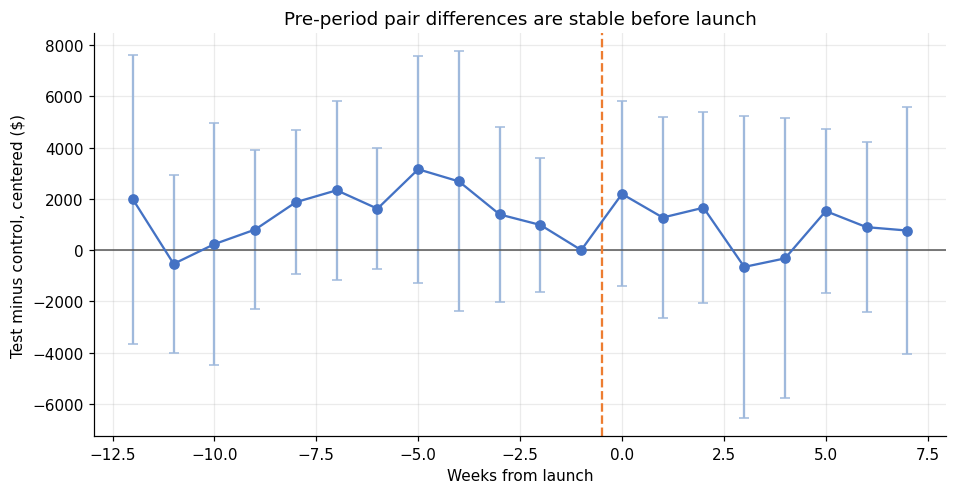

In [11]:
def event_study_by_pair(
    panel: pd.DataFrame,
    assignment: pd.DataFrame,
    test_start: str | pd.Timestamp,
    pre_weeks: int = 12,
    post_weeks: int = 8,
) -> pd.DataFrame:
    """Return pair-difference event-study means and standard errors."""
    work = panel.copy()
    work["week"] = pd.to_datetime(work["week"])
    work = work.merge(assignment[["geo", "pair", "role"]], on="geo", how="inner")
    start = pd.Timestamp(test_start)
    work["relative_week"] = ((work["week"] - start).dt.days // 7).astype(int)
    work = work.loc[work["relative_week"].between(-pre_weeks, post_weeks - 1)]
    wide = work.pivot_table(index=["pair", "relative_week"], columns="role", values="revenue")
    wide["pair_difference"] = wide["test"] - wide["control"]
    baseline = wide.xs(-1, level="relative_week")["pair_difference"]
    centered = wide["pair_difference"] - wide.index.get_level_values("pair").map(baseline)
    summary = centered.groupby(level="relative_week").agg(["mean", "std", "count"]).reset_index()
    summary["se"] = summary["std"] / np.sqrt(summary["count"])
    return summary[["relative_week", "mean", "se"]]


event_study = event_study_by_pair(panel, assignment, DESIGN["test_start"])
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.errorbar(
    event_study["relative_week"],
    event_study["mean"],
    yerr=1.96 * event_study["se"],
    fmt="o-",
    color="#4472c4",
    ecolor="#9fb9dc",
    capsize=3,
)
ax.axhline(0, color="#555555", lw=1)
ax.axvline(-0.5, color="#ed7d31", lw=1.5, ls="--")
ax.set(title="Pre-period pair differences are stable before launch", xlabel="Weeks from launch", ylabel="Test minus control, centered ($)")
fig.tight_layout()
plt.show()
plt.close(fig)

## Step 8: Synthetic Control as a Robustness Companion

DiD uses the randomized matched controls directly. A second view builds a
weighted blend from every untreated geography. Donor series are rescaled to
the treated aggregate's pre-period level, and non-negative weights are chosen
to minimize pre-period squared error.

In [12]:
def fit_synthetic_control(
    panel: pd.DataFrame,
    assignment: pd.DataFrame,
    test_start: str | pd.Timestamp,
    test_end: str | pd.Timestamp,
    spend_multiplier: float = 1.25,
) -> dict:
    """Fit a convex donor blend and return the actual/counterfactual series."""
    work = panel.copy()
    work["week"] = pd.to_datetime(work["week"])
    pivot = work.pivot(index="week", columns="geo", values="revenue").sort_index()
    treated_geos = assignment.loc[assignment["role"] == "test", "geo"].tolist()
    donor_geos = [geo for geo in pivot.columns if geo not in treated_geos]
    actual = pivot[treated_geos].sum(axis=1)
    donors = pivot[donor_geos]
    pre_mask = actual.index < pd.Timestamp(test_start)

    treated_pre_mean = float(actual.loc[pre_mask].mean())
    donor_pre_means = donors.loc[pre_mask].mean().replace(0.0, np.nan)
    scaled_donors = donors.multiply(treated_pre_mean / donor_pre_means, axis=1)
    x_pre = scaled_donors.loc[pre_mask].to_numpy()
    y_pre = actual.loc[pre_mask].to_numpy()

    scale = float(np.mean(y_pre))

    def objective(weights: np.ndarray) -> float:
        residual = (y_pre - x_pre @ weights) / scale
        return float(np.mean(np.square(residual)))

    n_donors = len(donor_geos)
    result = minimize(
        objective,
        x0=np.full(n_donors, 1.0 / n_donors),
        bounds=[(0.0, 1.0)] * n_donors,
        constraints={"type": "eq", "fun": lambda weights: weights.sum() - 1.0},
        method="SLSQP",
        options={"maxiter": 2_000, "ftol": 1e-8},
    )
    if not result.success:
        raise RuntimeError(f"Synthetic-control optimization failed: {result.message}")

    synthetic = pd.Series(scaled_donors.to_numpy() @ result.x, index=actual.index)
    series = pd.DataFrame(
        {
            "week": actual.index,
            "actual": actual.to_numpy(),
            "synthetic": synthetic.to_numpy(),
        }
    )
    series["gap"] = series["actual"] - series["synthetic"]
    post_mask = series["week"].between(pd.Timestamp(test_start), pd.Timestamp(test_end))
    treated_panel = work.loc[
        work["geo"].isin(treated_geos)
        & work["week"].between(pd.Timestamp(test_start), pd.Timestamp(test_end))
    ]
    incremental_spend = float(
        (treated_panel["spend"] * (spend_multiplier - 1.0) / spend_multiplier).sum()
    )
    return {
        "series": series,
        "weights": pd.Series(result.x, index=donor_geos).sort_values(ascending=False),
        "pre_rmse": float(np.sqrt(np.mean(np.square(series.loc[~post_mask, "gap"])))),
        "incremental_revenue": float(series.loc[post_mask, "gap"].sum()),
        "roas": float(series.loc[post_mask, "gap"].sum() / incremental_spend),
    }


synthetic = fit_synthetic_control(
    panel,
    assignment,
    DESIGN["test_start"],
    DESIGN["test_end"],
    DESIGN["spend_multiplier"],
)
print(f"Synthetic-control pre-period RMSE: ${synthetic['pre_rmse']:,.0f}")
print(f"Synthetic-control ROAS: {synthetic['roas']:.3f}")
print("Largest donor weights:")
print(synthetic["weights"].head(6).to_string())

Synthetic-control pre-period RMSE: $7,477
Synthetic-control ROAS: 0.186
Largest donor weights:
Geo 07   0.226
Geo 11   0.163
Geo 03   0.094
Geo 13   0.081
Geo 10   0.072
Geo 01   0.059


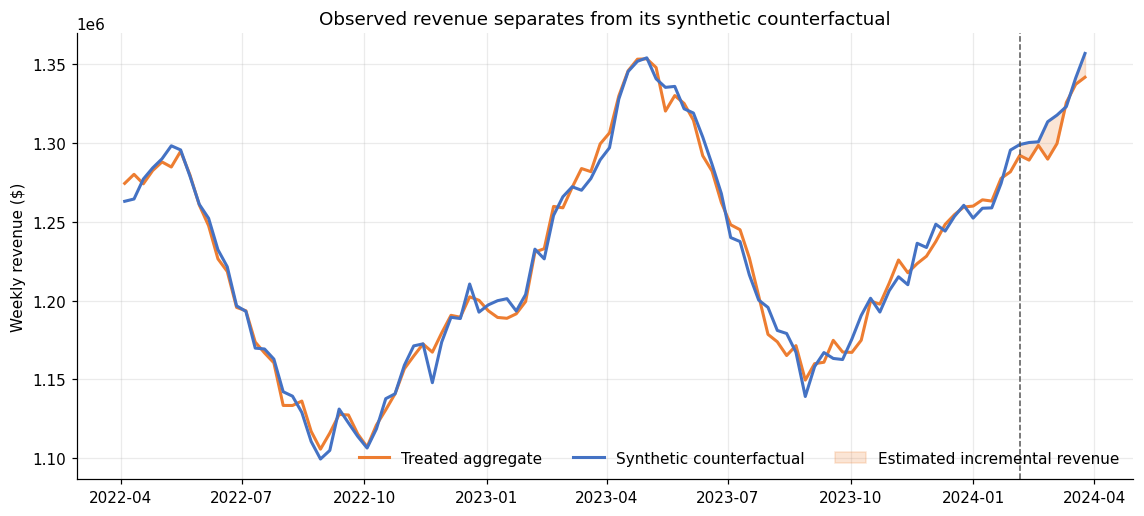

In [13]:
synthetic_series = synthetic["series"]
post_mask = synthetic_series["week"].between(
    pd.Timestamp(DESIGN["test_start"]), pd.Timestamp(DESIGN["test_end"])
)
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.plot(synthetic_series["week"], synthetic_series["actual"], lw=2, color="#ed7d31", label="Treated aggregate")
ax.plot(synthetic_series["week"], synthetic_series["synthetic"], lw=2, color="#4472c4", label="Synthetic counterfactual")
ax.fill_between(
    synthetic_series.loc[post_mask, "week"],
    synthetic_series.loc[post_mask, "actual"],
    synthetic_series.loc[post_mask, "synthetic"],
    color="#ed7d31",
    alpha=0.20,
    label="Estimated incremental revenue",
)
ax.axvline(pd.Timestamp(DESIGN["test_start"]), color="#555555", ls="--", lw=1)
ax.set(title="Observed revenue separates from its synthetic counterfactual", ylabel="Weekly revenue ($)")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
save_chapter_figure(fig, "actual_vs_synthetic_gap.png")
plt.show()
plt.close(fig)

## Step 9: Placebo Battery

Two questions try to falsify the result. In-space randomization asks what DiD
would report under every possible within-pair assignment. In-time placebos
move the launch to earlier historical windows where no intervention occurred.

In [14]:
def randomization_placebos(
    panel: pd.DataFrame,
    assignment: pd.DataFrame,
    test_start: str | pd.Timestamp,
    test_end: str | pd.Timestamp,
    spend_multiplier: float = 1.25,
) -> pd.DataFrame:
    """Enumerate all within-pair assignments for design-based inference."""
    actual = fit_did(panel, assignment, test_start, test_end, spend_multiplier)
    denom_per_geo_week = actual["incremental_spend"] / actual["n_treated_geo_weeks"]
    frame = actual["analysis"]
    means = frame.groupby(["pair", "role", "post"])["revenue"].mean().unstack("post")
    changes = (means[1] - means[0]).unstack("role")
    pair_effects = (changes["test"] - changes["control"]).to_numpy()

    rows = []
    for assignment_id, signs in enumerate(
        itertools.product([-1.0, 1.0], repeat=len(pair_effects))
    ):
        # Swapping treatment and control within a pair flips that pair's DiD.
        placebo_effect = float(np.mean(np.asarray(signs) * pair_effects))
        rows.append(
            {
                "assignment_id": assignment_id,
                "placebo_roas": placebo_effect / denom_per_geo_week,
            }
        )
    return pd.DataFrame(rows)


def time_placebos(
    panel: pd.DataFrame,
    assignment: pd.DataFrame,
    duration_weeks: int = 8,
    spend_multiplier: float = 1.25,
) -> pd.DataFrame:
    """Move the launch across non-overlapping historical windows."""
    history = panel.copy()
    history["week"] = pd.to_datetime(history["week"])
    history = history.loc[history["week"] < pd.Timestamp(DESIGN["test_start"])]
    weeks = np.array(sorted(history["week"].unique()))
    start_indices = range(24, len(weeks) - duration_weeks + 1, duration_weeks)
    rows = []
    for start_index in start_indices:
        start = pd.Timestamp(weeks[start_index])
        end = pd.Timestamp(weeks[start_index + duration_weeks - 1])
        frame = prepare_did_panel(history, assignment, start, end)
        model = smf.ols(
            "revenue ~ C(geo) + C(pair):post + treat:post", data=frame
        ).fit(
            cov_type="cluster", cov_kwds={"groups": frame["geo"]}
        )
        treated_post = (frame["treat"] == 1) & (frame["post"] == 1)
        # Placebo windows carry un-inflated baseline spend, so the hypothetical
        # incremental spend is spend * (m - 1). fit_did's real test window sees
        # already-inflated spend and therefore uses spend * (m - 1) / m.
        planned_spend = float(
            (frame.loc[treated_post, "spend"] * (spend_multiplier - 1.0)).sum()
        )
        spend_per_geo_week = planned_spend / int(treated_post.sum())
        rows.append(
            {
                "fake_start": start,
                "placebo_roas": float(model.params["treat:post"] / spend_per_geo_week),
            }
        )
    return pd.DataFrame(rows)


space_placebos = randomization_placebos(
    panel, assignment, DESIGN["test_start"], DESIGN["test_end"], DESIGN["spend_multiplier"]
)
time_placebo_results = time_placebos(
    panel, assignment, DESIGN["test_weeks"], DESIGN["spend_multiplier"]
)
randomization_p = float(
    (np.abs(space_placebos["placebo_roas"]) >= abs(did["roas"]) - 1e-12).mean()
)
print(f"Randomization-inference p-value: {randomization_p:.3f}")
print(f"In-time placebo mean ROAS: {time_placebo_results['placebo_roas'].mean():.3f}")

Randomization-inference p-value: 0.117
In-time placebo mean ROAS: 0.053


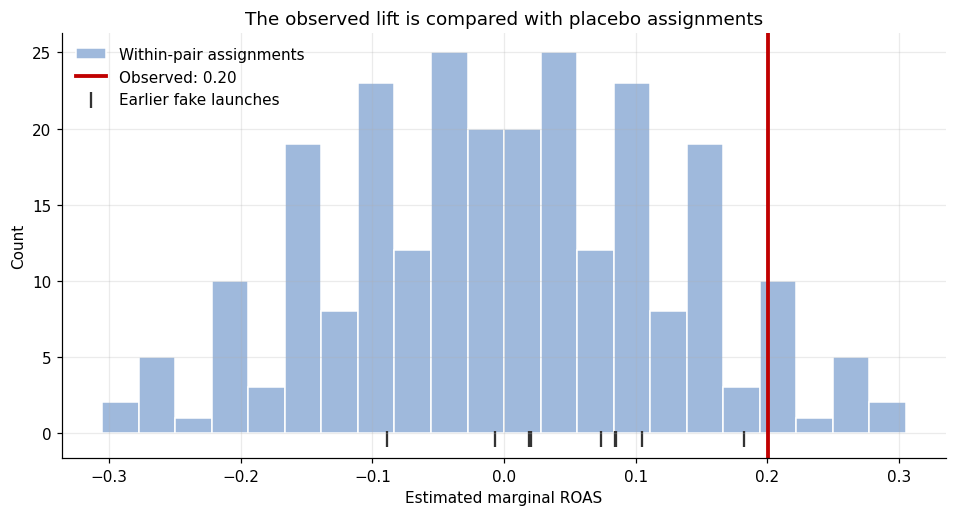

In [15]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.hist(space_placebos["placebo_roas"], bins=22, color="#9fb9dc", edgecolor="white", label="Within-pair assignments")
ax.axvline(did["roas"], color="#c00000", lw=2.5, label=f"Observed: {did['roas']:.2f}")
ax.scatter(
    time_placebo_results["placebo_roas"],
    np.full(len(time_placebo_results), -0.4),
    marker="|",
    s=120,
    color="#333333",
    label="Earlier fake launches",
    clip_on=False,
)
ax.set(title="The observed lift is compared with placebo assignments", xlabel="Estimated marginal ROAS", ylabel="Count")
ax.legend(frameon=False)
fig.tight_layout()
save_chapter_figure(fig, "placebo_distribution.png")
plt.show()
plt.close(fig)

## Step 10: Lift to ROAS

The point estimate identifies the return on the incremental dollars in these
markets during this window. It is a policy effect, not a permanent property of
the channel.

In [16]:
print(
    pd.DataFrame(
        {
            "Estimate": ["Incremental revenue", "Incremental spend", "Marginal ROAS", "ROAS SE", "95% CI"],
            "Value": [
                f"${did['coefficient'] * DESIGN['n_pairs'] * DESIGN['test_weeks']:,.0f}",
                f"${did['incremental_spend']:,.0f}",
                f"{did['roas']:.3f}",
                f"{did['roas_se']:.3f}",
                f"[{did['ci_low']:.3f}, {did['ci_high']:.3f}]",
            ],
        }
    ).to_string(index=False)
)

           Estimate          Value
Incremental revenue       $-84,590
  Incremental spend      $-421,906
      Marginal ROAS          0.200
            ROAS SE          0.075
             95% CI [0.040, 0.361]


## Step 10b: The Decision Rule, and Whether the Design Can Deliver It

The minimum detectable effect and the business hurdle are different numbers.
The MDE is the smallest effect this panel can tell apart from zero. The hurdle
is the smallest effect that would justify keeping the budget: a Search dollar
has to return more than `1 / contribution margin` in revenue to pay for
itself. At a 40% margin that is a ROAS of 2.50.

Freeze the rule before the result exists, then check that the design can
actually produce each verdict. Re-plant a known effect at several candidate
truths, re-randomize the assignment, and count how often the frozen rule says
cut, hold, or keep.

In [17]:
def decision_verdict(estimate, hurdle):
    """Frozen rule: keep only if the interval clears the hurdle, cut only if it misses."""
    if estimate["ci_low"] >= hurdle:
        return "keep"
    if estimate["ci_high"] < hurdle:
        return "cut"
    return "hold"


def decision_power(
    panel_frame,
    assignment_frame,
    candidate_roas,
    duration_weeks=DESIGN["test_weeks"],
    spend_multiplier=DESIGN["spend_multiplier"],
    hurdle=DESIGN["hurdle_roas"],
    n_sim=200,
    seed=DESIGN["seed"],
):
    """P(cut) / P(hold) / P(keep) under the frozen rule, by true ROAS.

    Runs on pre-test history only, exactly like `simulate_power_grid`, so it
    never touches the planted effect the notebook has not opened yet.
    """
    rng = np.random.default_rng(seed)
    history = panel_frame.copy()
    history["week"] = pd.to_datetime(history["week"])
    history = history.loc[history["week"] < pd.Timestamp(DESIGN["test_start"])].copy()
    weeks = np.array(sorted(history["week"].unique()))
    if len(weeks) < duration_weeks + 36:
        raise ValueError("Decision-power simulation needs at least 36 pre-weeks plus the window.")

    rows = []
    for true_roas in candidate_roas:
        counts = {"cut": 0, "hold": 0, "keep": 0}
        for _ in range(n_sim):
            randomized = _randomize_within_pairs(assignment_frame, rng)
            end_index = int(rng.integers(duration_weeks + 35, len(weeks)))
            window_end = pd.Timestamp(weeks[end_index])
            window_start = pd.Timestamp(weeks[end_index - duration_weeks + 1])
            base = history.loc[history["week"] <= window_end].copy()
            roles = randomized.set_index("geo")["role"]
            treated_window = (
                base["geo"].map(roles).eq("test")
                & base["week"].between(window_start, window_end)
            )
            # Pre-period spend is un-inflated, so the planned change is
            # spend * (m - 1); apply it, then let fit_did recover the same
            # amount from the already-changed series.
            planned_change = base.loc[treated_window, "spend"] * (spend_multiplier - 1.0)
            injected = base.copy()
            injected.loc[treated_window, "spend"] = (
                injected.loc[treated_window, "spend"] * spend_multiplier
            )
            injected.loc[treated_window, "revenue"] = (
                injected.loc[treated_window, "revenue"] + true_roas * planned_change.to_numpy()
            )
            estimate = fit_did(
                injected, randomized, window_start, window_end,
                spend_multiplier=spend_multiplier,
            )
            counts[decision_verdict(estimate, hurdle)] += 1
        rows.append({
            "True ROAS": true_roas,
            "P(cut)": counts["cut"] / n_sim,
            "P(hold)": counts["hold"] / n_sim,
            "P(keep)": counts["keep"] / n_sim,
        })
    return pd.DataFrame(rows)


power_of_decision = decision_power(
    panel, assignment,
    candidate_roas=(0.2, 1.0, DESIGN["hurdle_roas"], 3.0),
)
print(f"Frozen rule: keep if the 95% CI low >= {DESIGN['hurdle_roas']}, "
      f"cut if the 95% CI high < {DESIGN['hurdle_roas']}, otherwise hold.")
print(power_of_decision.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print()
print("The design is decisive about cutting and weak about keeping. That is the")
print("right asymmetry here: the question on the table is whether to remove")
print("budget, and the evidence needed to answer it is far coarser than the")
print("evidence needed to distinguish the effect from zero.")

Frozen rule: keep if the 95% CI low >= 2.5, cut if the 95% CI high < 2.5, otherwise hold.
 True ROAS  P(cut)  P(hold)  P(keep)
      0.20    1.00     0.00     0.00
      1.00    1.00     0.00     0.00
      2.50    0.00     1.00     0.00
      3.00    0.00     0.83     0.17

The design is decisive about cutting and weak about keeping. That is the
right asymmetry here: the question on the table is whether to remove
budget, and the evidence needed to answer it is far coarser than the
evidence needed to distinguish the effect from zero.


## Step 10c: How Wide Is the Uncertainty, Really?

Assignment was eight coin flips, one per matched pair, but the estimator above
clusters on 16 markets. Both readings are defensible and they are not the same
width, so pre-specify one and report the other. Section 6.4 needs the number
that goes into the prior, and a prior built on the narrower of two defensible
widths is a choice that should be visible.

In [18]:
readings = []
for unit, label in (("geo", "market (16 clusters)"), ("pair", "matched pair (8 clusters)")):
    estimate = fit_did(
        panel, assignment, DESIGN["test_start"], DESIGN["test_end"],
        spend_multiplier=DESIGN["spend_multiplier"], cluster_by=unit,
    )
    readings.append({
        "Clustered on": label,
        "ROAS": round(estimate["roas"], 3),
        "SE": round(estimate["roas_se"], 3),
        "95% CI": f"[{estimate['ci_low']:.3f}, {estimate['ci_high']:.3f}]",
        "Verdict": decision_verdict(estimate, DESIGN["hurdle_roas"]),
    })
print(pd.DataFrame(readings).to_string(index=False))
print()
print("The point estimate is identical; only the width moves. Both verdicts are")
print("the same, because the hurdle sits far above either interval. The width")
print("still matters downstream: it is what Section 6.4 turns into a prior, so")
print("the calibration there is run at both widths and the guardrail is checked")
print("against each.")

             Clustered on  ROAS    SE          95% CI Verdict
     market (16 clusters) 0.200 0.075  [0.040, 0.361]     cut
matched pair (8 clusters) 0.200 0.110 [-0.060, 0.461]     cut

The point estimate is identical; only the width moves. Both verdicts are
the same, because the hurdle sits far above either interval. The width
still matters downstream: it is what Section 6.4 turns into a prior, so
the calibration there is run at both widths and the guardrail is checked
against each.


## Step 11: Open the Ground Truth

Only now do we load the file that records the planted incremental outcome.
Recovery is judged against the true marginal ROAS, not against a convenient
narrative.

In [19]:
truth = pd.read_csv(TRUTH_PATH, parse_dates=["week"])
true_roas = float(truth["true_roas"].iloc[0])
true_incremental_revenue = float(truth["true_incremental_revenue_total"].iloc[0])
print(f"Estimated ROAS: {did['roas']:.3f}")
print(f"Planted ROAS:   {true_roas:.3f}")
print(f"Absolute error: {abs(did['roas'] - true_roas):.3f}")
print(f"Planted incremental revenue: ${true_incremental_revenue:,.0f}")

Estimated ROAS: 0.200
Planted ROAS:   0.200
Absolute error: 0.000
Planted incremental revenue: $-84,381


## Step 12: Experiment Evidence Package

A calibration handoff needs more than one number. Preserve the assignment,
dates, spend contrast, uncertainty, and estimand so the next model does not
silently reinterpret the experiment.

In [20]:
observed_post_spend = float(test_rows.loc[test_rows["post"] == 1, "spend"].sum())
baseline_post_spend = observed_post_spend / DESIGN["spend_multiplier"]
evidence_package = pd.DataFrame(
    {
        "Field": [
            "Channel",
            "Design",
            "Test dates",
            "Baseline spend",
            "Spend removed",
            "Marginal ROAS",
            "Standard error",
            "95% confidence interval",
            "Estimand",
        ],
        "Value": [
            DESIGN["channel"],
            "8 randomized matched geo pairs",
            f"{DESIGN['test_start']} to {DESIGN['test_end']}",
            f"${baseline_post_spend:,.0f}",
            f"${abs(did['incremental_spend']):,.0f}",
            f"{did['roas']:.3f}",
            f"{did['roas_se']:.3f}",
            f"[{did['ci_low']:.3f}, {did['ci_high']:.3f}]",
            "Revenue given up by a 30% spend cut in selected geos over eight weeks",
        ],
    }
)
print(evidence_package.to_string(index=False))

                  Field                                                                 Value
                Channel                                                         Google Search
                 Design                                        8 randomized matched geo pairs
             Test dates                                              2024-02-05 to 2024-03-25
         Baseline spend                                                            $1,406,355
          Spend removed                                                              $421,906
          Marginal ROAS                                                                 0.200
         Standard error                                                                 0.075
95% confidence interval                                                        [0.040, 0.361]
               Estimand Revenue given up by a 30% spend cut in selected geos over eight weeks


This numbers-only handoff is the bridge to Step 15 of
`sec6.2_6.4_mmm_meridian.ipynb`, which translates this ROAS 0.200 with
SE 0.075 into a LogNormal prior. Report the *delivered* contrast, not the
planned one: markets rarely land exactly on the planned spend change, and the
model should be calibrated on what actually happened. Here they coincide,
because the panel is synthetic and delivery is exact. The notebooks do not read each other's
files: the estimand and uncertainty must be reviewed before calibration.